In [2]:
import pandas as pd
import numpy as np
import os
import json
from glob import glob
from collections import Counter

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB3, DenseNet121, InceptionV3, MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

from sklearn.model_selection import train_test_split

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS = 25
VALIDATION_SPLIT = 0.2
RANDOM_STATE = 42

CLASSES = [
    'akiec','bcc','bkl','df','mel','nv','vasc'
]

In [4]:
BASE_DIR = os.path.abspath("..")   # go one level up from SDP
DATA_DIR = os.path.join(BASE_DIR, "data")

CSV_PATH = os.path.join(DATA_DIR, "HAM10000_metadata.csv")

metadata = pd.read_csv(CSV_PATH)

image_paths = {
    os.path.splitext(os.path.basename(x))[0]: x
    for x in glob(os.path.join(DATA_DIR, "HAM10000_images_part_*/*.jpg"))
}

metadata['path'] = metadata['image_id'].map(image_paths.get)
metadata = metadata.dropna()

metadata.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,path
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,/Users/divydadheech/Documents/Academics/SDP3/d...
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,/Users/divydadheech/Documents/Academics/SDP3/d...
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,/Users/divydadheech/Documents/Academics/SDP3/d...
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,/Users/divydadheech/Documents/Academics/SDP3/d...
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,/Users/divydadheech/Documents/Academics/SDP3/d...


In [5]:
train_df, val_df = train_test_split(
    metadata,
    test_size=VALIDATION_SPLIT,
    random_state=RANDOM_STATE,
    stratify=metadata['dx']
)

print(f"Training samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")

Training samples: 7966
Validation samples: 1992


In [6]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_dataframe(
    train_df,
    x_col='path',
    y_col='dx',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_gen = val_datagen.flow_from_dataframe(
    val_df,
    x_col='path',
    y_col='dx',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

Found 7966 validated image filenames belonging to 7 classes.
Found 1992 validated image filenames belonging to 7 classes.


In [7]:
def build_classifier(base_model_fn, name, unfreeze_top=15):
    base_model = base_model_fn(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )

    # Freeze all
    for layer in base_model.layers:
        layer.trainable = False

    # Unfreeze top layers
    for layer in base_model.layers[-unfreeze_top:]:
        layer.trainable = True

    x = base_model.output
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(len(CLASSES), activation='softmax')(x)

    model = models.Model(inputs=base_model.input, outputs=outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=3e-5),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
        metrics=['accuracy']
    )

    return model

In [8]:
def build_efficientnet():
    return build_classifier(EfficientNetB3, "EfficientNetB3")

def build_densenet():
    return build_classifier(DenseNet121, "DenseNet121")

def build_inception():
    return build_classifier(InceptionV3, "InceptionV3")

def build_mobilenet():
    return build_classifier(MobileNetV2, "MobileNetV2")

In [9]:
competitors = {
    "DenseNet121": build_densenet,
}
results = []
best_model = None
best_acc = 0
winning_model_name = None

os.makedirs('../backend', exist_ok=True)

for name, builder in competitors.items():
    print(f"\n🔥 Training {name}")

    model = builder()

    callbacks = [
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.3,
            patience=2,
            min_lr=1e-6,
            verbose=1
        ),
        EarlyStopping(
            monitor='val_loss',
            patience=4,
            restore_best_weights=True,
            verbose=1
        )
    ]

    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=EPOCHS,
        callbacks=callbacks,
        verbose=1
    )

    val_acc = max(history.history['val_accuracy'])
    train_acc = history.history['accuracy'][-1]
    val_loss = min(history.history['val_loss'])
    params = model.count_params()

    results.append({
        "name": f"{name}_v2",
        "val_accuracy": round(val_acc, 4),
        "train_accuracy": round(train_acc, 4),
        "val_loss": round(val_loss, 4),
        "params": params
    })

    if val_acc > best_acc:
        best_acc = val_acc
        best_model = model
        winning_model_name = f"{name}_v2"


🔥 Training DenseNet121


2026-05-04 08:54:44.572377: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2026-05-04 08:54:44.572540: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-05-04 08:54:44.572545: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-05-04 08:54:44.572836: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-04 08:54:44.572855: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Epoch 1/15


2026-05-04 08:54:49.988507: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


498/498 ━━━━━━━━━━━━━━━━━━━━ 207s 387ms/step - accuracy: 0.3297 - loss: 2.3938 - val_accuracy: 0.5502 - val_loss: 1.5257 - learning_rate: 3.0000e-05
Epoch 2/15
498/498 ━━━━━━━━━━━━━━━━━━━━ 196s 393ms/step - accuracy: 0.4986 - loss: 1.9327 - val_accuracy: 0.6918 - val_loss: 1.1851 - learning_rate: 3.0000e-05
Epoch 3/15
498/498 ━━━━━━━━━━━━━━━━━━━━ 238s 476ms/step - accuracy: 0.5793 - loss: 1.7705 - val_accuracy: 0.7123 - val_loss: 1.1623 - learning_rate: 3.0000e-05
Epoch 4/15
498/498 ━━━━━━━━━━━━━━━━━━━━ 305s 609ms/step - accuracy: 0.6144 - loss: 1.6781 - val_accuracy: 0.7224 - val_loss: 1.1405 - learning_rate: 3.0000e-05
Epoch 5/15
498/498 ━━━━━━━━━━━━━━━━━━━━ 255s 510ms/step - accuracy: 0.6280 - loss: 1.6419 - val_accuracy: 0.7294 - val_loss: 1.1317 - learning_rate: 3.0000e-05
Epoch 6/15
498/498 ━━━━━━━━━━━━━━━━━━━━ 296s 593ms/step - accuracy: 0.6426 - loss: 1.5608 - val_accuracy: 0.7440 - val_loss: 1.1037 - learning_rate: 3.0000e-05
Epoch 7/15
498/498 ━━━━━━━━━━━━━━━━━━━━ 295s 590ms/

In [12]:
print(train_gen.class_indices)

{'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}


In [13]:
print(history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss', 'learning_rate'])


In [10]:
best_model.save('../backend/skin_disease_model_v2.keras')

print(f"\n🏆 Best Model: {winning_model_name}")
print("✅ Saved as ../backend/skin_disease_model_v2.keras")


🏆 Best Model: DenseNet121_v2
✅ Saved as ../backend/skin_disease_model_v2.keras


In [11]:
# --- Results Summary ---
results_df = pd.DataFrame(results).sort_values('val_accuracy', ascending=False)
results_df['rank'] = range(1, len(results_df) + 1)
results_df['winner'] = results_df['name'] == winning_model_name

print('\n📊 Tournament Leaderboard:')
print(results_df[['rank', 'name', 'val_accuracy', 'train_accuracy', 'val_loss', 'params']].to_string(index=False))

# Save results for frontend reference
results_json = results_df.to_dict('records')

with open('../backend/tournament_results.json', 'w') as f:
    json.dump(results_json, f, indent=2)

print('\n✅ Results saved to ../backend/tournament_results.json')


📊 Tournament Leaderboard:
 rank           name  val_accuracy  train_accuracy  val_loss  params
    1 DenseNet121_v2        0.7811          0.7212    0.9956 7305799

✅ Results saved to ../backend/tournament_results.json


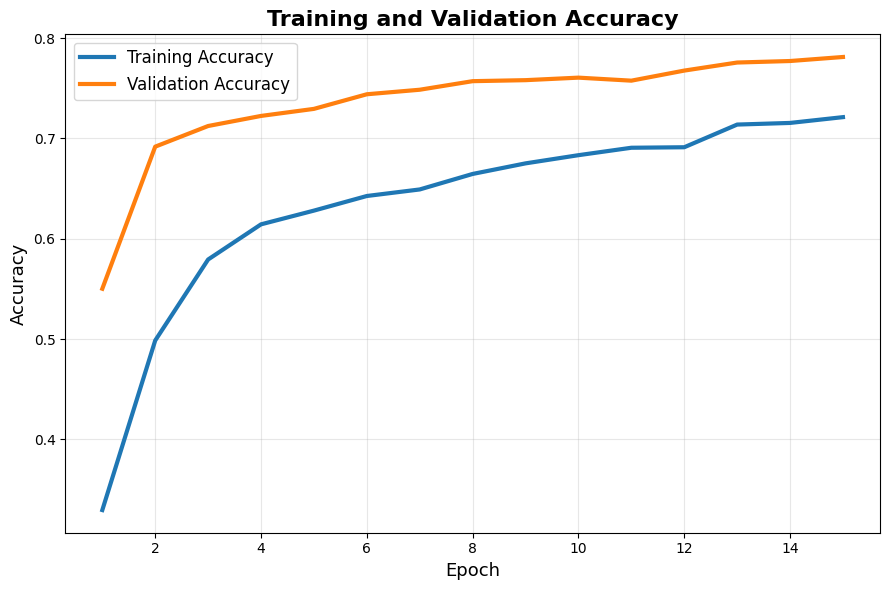

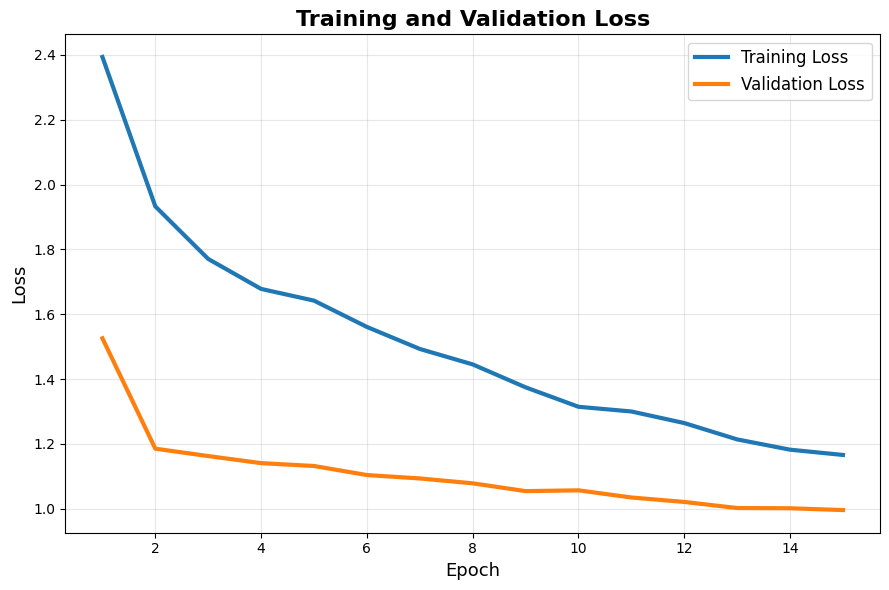

Saved both figures


In [15]:
import matplotlib.pyplot as plt

acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]

loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs = range(1, len(acc) + 1)

# -------------------------
# Figure 6.1 Accuracy
# -------------------------
plt.figure(figsize=(9,6))

plt.plot(
    epochs,
    acc,
    linewidth=3,
    label="Training Accuracy"
)

plt.plot(
    epochs,
    val_acc,
    linewidth=3,
    label="Validation Accuracy"
)

plt.title(
    "Training and Validation Accuracy",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Epoch", fontsize=13)
plt.ylabel("Accuracy", fontsize=13)

plt.grid(alpha=0.3)
plt.legend(fontsize=12)

plt.tight_layout()

plt.savefig(
    "Figure_6_1_Accuracy_Curve.png",
    dpi=300
)

plt.show()


# -------------------------
# Figure 6.2 Loss
# -------------------------
plt.figure(figsize=(9,6))

plt.plot(
    epochs,
    loss,
    linewidth=3,
    label="Training Loss"
)

plt.plot(
    epochs,
    val_loss,
    linewidth=3,
    label="Validation Loss"
)

plt.title(
    "Training and Validation Loss",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Epoch", fontsize=13)
plt.ylabel("Loss", fontsize=13)

plt.grid(alpha=0.3)
plt.legend(fontsize=12)

plt.tight_layout()

plt.savefig(
    "Figure_6_2_Loss_Curve.png",
    dpi=300
)

plt.show()

print("Saved both figures")

In [3]:
print("history exists:", "history" in globals())
print("best_model exists:", "best_model" in globals())
print("train_df exists:", "train_df" in globals())
print("val_df exists:", "val_df" in globals())
print("train_gen exists:", "train_gen" in globals())
print("val_gen exists:", "val_gen" in globals())

history exists: False
best_model exists: False
train_df exists: False
val_df exists: False
train_gen exists: False
val_gen exists: False


Found 1992 validated image filenames belonging to 7 classes.


2026-05-04 14:32:13.003324: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2026-05-04 14:32:13.003487: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-05-04 14:32:13.003490: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-05-04 14:32:13.003705: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-04 14:32:13.003719: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


✅ Model loaded
✅ Validation set loaded


2026-05-04 14:32:16.140613: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


125/125 ━━━━━━━━━━━━━━━━━━━━ 49s 361ms/step


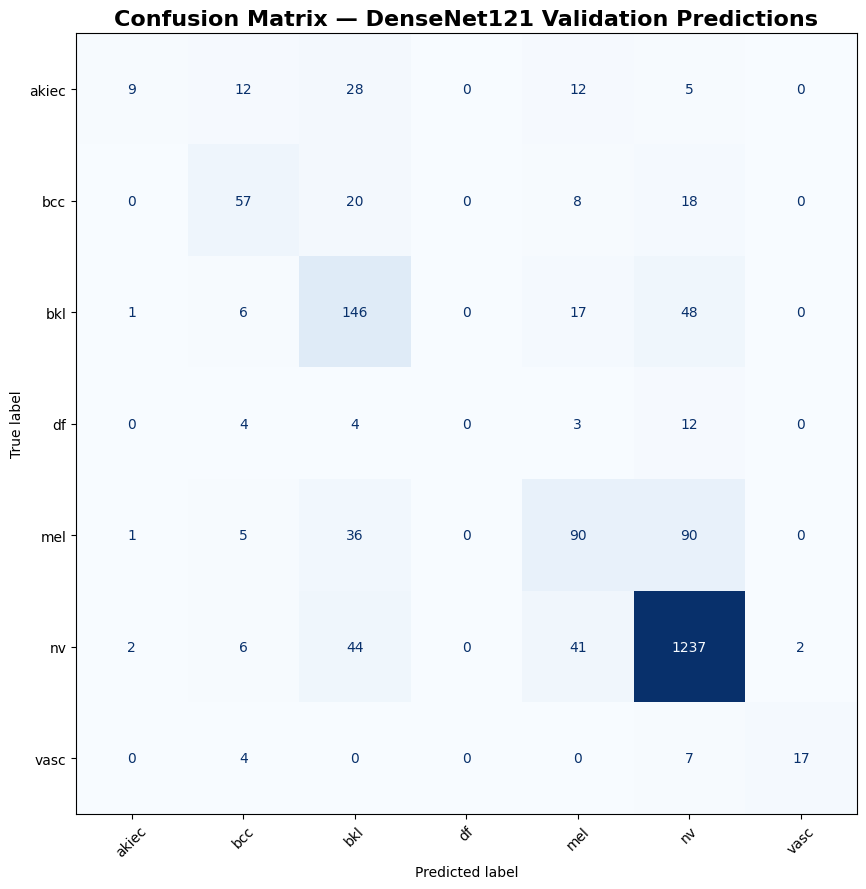

✅ Saved: Figure_6_3_Confusion_Matrix.png


In [4]:
import os
from glob import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ----------------------------
# SETTINGS
# ----------------------------
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
VALIDATION_SPLIT = 0.2
RANDOM_STATE = 42

# ----------------------------
# LOAD DATA
# ----------------------------
BASE_DIR = os.path.abspath("..")
DATA_DIR = os.path.join(BASE_DIR, "data")
CSV_PATH = os.path.join(DATA_DIR, "HAM10000_metadata.csv")

metadata = pd.read_csv(CSV_PATH)

image_paths = {
    os.path.splitext(os.path.basename(x))[0]: x
    for x in glob(os.path.join(DATA_DIR, "HAM10000_images_part_*/*.jpg"))
}

metadata["path"] = metadata["image_id"].map(image_paths.get)
metadata = metadata.dropna()

# same split as training
_, val_df = train_test_split(
    metadata,
    test_size=VALIDATION_SPLIT,
    random_state=RANDOM_STATE,
    stratify=metadata["dx"]
)

# ----------------------------
# VALIDATION GENERATOR
# ----------------------------
val_datagen = ImageDataGenerator(rescale=1./255)

val_gen = val_datagen.flow_from_dataframe(
    val_df,
    x_col="path",
    y_col="dx",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

# ----------------------------
# LOAD MODEL
# ----------------------------
model = tf.keras.models.load_model(
    "../backend/skin_disease_model_v2.keras"
)

print("✅ Model loaded")
print("✅ Validation set loaded")

# ----------------------------
# PREDICT
# ----------------------------
pred_probs = model.predict(val_gen, verbose=1)

y_pred = np.argmax(pred_probs, axis=1)
y_true = val_gen.classes

labels = list(val_gen.class_indices.keys())

# ----------------------------
# CONFUSION MATRIX
# ----------------------------
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(11, 9))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot(
    ax=ax,
    cmap="Blues",
    colorbar=False,
    values_format="d"
)

plt.title(
    "Confusion Matrix — DenseNet121 Validation Predictions",
    fontsize=16,
    fontweight="bold"
)

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(
    "Figure_6_3_Confusion_Matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Saved: Figure_6_3_Confusion_Matrix.png")